800


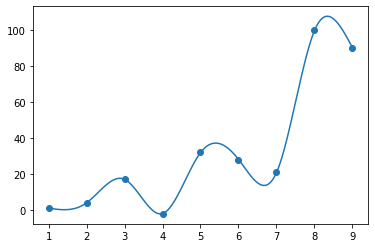

In [54]:
import numpy as np
import matplotlib.pyplot as plt
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])           # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


def custom_cubic_spline(x, y):
    evalx = x
    evaly = y
    a, b, c, d = setup_tridiagonal_matrix(x, y)
    M = np.array([0.0, *thomas_algorithm(a, b, c, d), 0.0], dtype=float)
    length = 0
    for i in range(len(x)-1):
        length = length + ((x[i+1]-x[i]) * 100)
    yreturn = np.zeros(length)
    xreturn = np.linspace(x[0], x[len(x)-1], length)
    print(len(yreturn))
    for i in range(len(x)-1):
        xinterp = np.arange(x[i], x[i+1], 0.01)
        h = x[i+1]-x[i]
        yreturn[i * 100:i * 100 + ((x[i+1]-x[i]) * 100)] = (M[i]/(6 * h)) * (x[i+1]-xinterp)**3 + \
        (M[i+1]/(6 * h)) * (xinterp-x[i])**3 + (y[i]/h - (M[i] * h)/6) * (x[i+1]-xinterp) + \
        (y[i+1]/h - (M[i+1] * h)/6) * (xinterp-x[i])
            
        
    return xreturn, yreturn


x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1, 4, 17, -2, 32, 28, 21, 100, 90])


x_interp, y_interp = custom_cubic_spline(x, y)

plt.scatter(x, y)
plt.plot(x_interp, y_interp)
